In [434]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_replace, col
import seaborn as sns
from pyspark.sql.functions import col, count, isnan, when, corr, floor, ceil, regexp_replace, expr
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

In [435]:
spark = SparkSession.builder \
    .appName("CSCI316_FINAL_PROJECT_LOAN") \
    .getOrCreate()

### Read the csv
First we need to read the csv and see the shape of the data so we have the idea on how many columns that we're working on. We also need to know how many nulls contains in every columns to have the idea which columns that can we drop.

In [436]:
df = spark.read.csv('data.csv', header=True, inferSchema=True)
print(f"shape: {df.count()} rows x {len(df.columns)} col")

shape: 855969 rows x 73 col


In [437]:
df.limit(100)

id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NULL,10+ years,RENT,24000,Verified,01-12-2011,n,Borrower added ...,credit_card,Computer,860xx,AZ,27.65,0,01-01-1985,1,NULL,NULL,3,0,13648,83.7,9,f,0,0,5861.071414,5831.78,5000,861.07,0,0,0,01-01-2015,171.62,NULL,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000,Source Verified,01-12-2011,n,Borrower added ...,car,bike,309xx,GA,1,0,01-04-1999,5,NULL,NULL,3,0,1687,9.4,4,f,0,0,1008.71,1008.71,456.46,435.17,0,117.08,1.11,01-04-2013,119.66,NULL,01-09-2013,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,1
1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NULL,10+ years,RENT,12252,Not Verified,01-12-2011,n,NULL,small_business,real estate business,606xx,IL,8.72,0,01-11-2001,2,NULL,NULL,2,0,2956,98.5,10,f,0,0,3003.653644,3003.65,2400,603.65,0,0,0,01-06-2014,649.91,NULL,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200,Source Verified,01-12-2011,n,Borrower added ...,other,personel,917xx,CA,20,0,01-02-1996,1,35,NULL,10,0,5598,21,37,f,0,0,12226.30221,12226.3,10000,2209.33,16.97,0,0,01-01-2015,357.48,NULL,01-01-2015,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medica...,1 year,RENT,80000,Source Verified,01-12-2011,n,Borrower added ...,other,Personal,972xx,OR,17.94,0,01-01-1996,0,38,NULL,15,0,27783,53.9,38,f,766.9,766.9,3242.17,3242.17,2233.1,1009.07,0,0,0,01-01-2016,67.79,01-02-2016,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1075269,1311441,5000,5000,5000.0,36 months,7.9,156.46,A,A4,Veolia Transportaton,3 years,RENT,36000,Source Verified,01-12-2011,n,NULL,wedding,My wedding loan I...,852xx,AZ,11.2,0,01-11-2004,3,NULL,NULL,9,0,7963,28.3,12,f,0,0,5631.377753,5631.38,5000,631.38,0,0,0,01-01-2015,161.03,NULL,01-09-2015,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1069639,1304742,7000,7000,7000.0,60 months,15.96,170.08,C,C5,Southern Star Pho...,8 years,RENT,47004,Not Verified,01-12-2011,n,Borrower added ...,debt_consolidation,Loan,280xx,NC,23.51,0,01-07-2005,1,NULL,NULL,7,0,17726,85.6,11,f,1889.15,1889.15,8136.84,8136.84,5110.85,3025.99,0,0,0,01-01-2016,170.08,01-02-2016,01-01-2016,0,NULL,1,INDIVIDUAL,NULL,NULL,NULL,0,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,NULL,0
1072053,1288686,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,RENT,48000,Source Ver

In [438]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])

id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,pymnt_plan,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
0,0,0,0,0,0,0,0,0,0,49439,0,0,0,0,0,0,734155,1,33,1,1,1,1,1,1,439669,724613,72,57,47,475,17,14,15,21,12,10,9,3,3,2,5,8869,3,252751,102,99,642637,72,57,855343,855382,855418,143,67198,67224,842600,842616,842638,842647,843010,842655,844337,842670,842664,842668,842675,67311,842676,842672,842680,223


In [439]:
df.dtypes

[('id', 'int'),
 ('member_id', 'int'),
 ('loan_amnt', 'int'),
 ('funded_amnt', 'int'),
 ('funded_amnt_inv', 'double'),
 ('term', 'string'),
 ('int_rate', 'double'),
 ('installment', 'double'),
 ('grade', 'string'),
 ('sub_grade', 'string'),
 ('emp_title', 'string'),
 ('emp_length', 'string'),
 ('home_ownership', 'string'),
 ('annual_inc', 'string'),
 ('verification_status', 'string'),
 ('issue_d', 'string'),
 ('pymnt_plan', 'string'),
 ('desc', 'string'),
 ('purpose', 'string'),
 ('title', 'string'),
 ('zip_code', 'string'),
 ('addr_state', 'string'),
 ('dti', 'string'),
 ('delinq_2yrs', 'string'),
 ('earliest_cr_line', 'string'),
 ('inq_last_6mths', 'string'),
 ('mths_since_last_delinq', 'string'),
 ('mths_since_last_record', 'string'),
 ('open_acc', 'string'),
 ('pub_rec', 'string'),
 ('revol_bal', 'string'),
 ('revol_util', 'string'),
 ('total_acc', 'string'),
 ('initial_list_status', 'string'),
 ('out_prncp', 'string'),
 ('out_prncp_inv', 'string'),
 ('total_pymnt', 'string'),
 ('t

## EDA
We're gonna explore the data to see what's going on in the data by visualizing it. 

### Target Imbalance
We need to know how imbalance is the target (default_ind). We're using **bar chart** to show the absolute count and proportions.

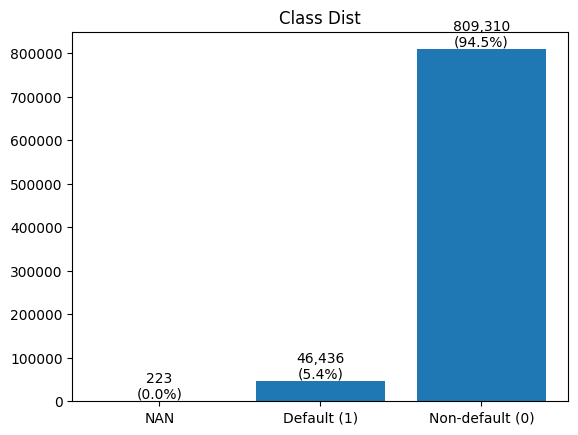

In [440]:
target_cnt = df.groupBy('default_ind').count().toPandas()
total = target_cnt['count'].sum()
target_cnt['pct'] = target_cnt['count']/total*100

labels = target_cnt['default_ind'].fillna('NAN').astype(str).replace(
    {'0.0': 'Non-default (0)', '1.0': 'Default (1)', 'Unknown': 'Unknown'}
)
plt.bar(labels, target_cnt['count'])
for i, (c, p) in enumerate(zip(target_cnt['count'], target_cnt['pct'])):
    plt.text(i, c, f'{c:,}\n({p:.1f}%)', ha='center', va='bottom')
plt.title("Class Dist")
plt.show()

In [441]:
df.select('loan_amnt','int_rate','annual_inc','dti','revol_util',
            'installment','total_acc','open_acc').describe().show()

+-------+------------------+-----------------+-----------------+------------------+--------------------+------------------+--------------------+-----------------+
|summary|         loan_amnt|         int_rate|       annual_inc|               dti|          revol_util|       installment|           total_acc|         open_acc|
+-------+------------------+-----------------+-----------------+------------------+--------------------+------------------+--------------------+-----------------+
|  count|            855969|           855969|           855969|            855968|              855494|            855969|              855952|           855897|
|   mean|14745.571334943204|13.19231960503263|75071.22927176018|18.123810127573343|   55.91715695821104|436.23807183435855|  25.968200584869795|11.54296815097585|
| stddev| 8425.340005005293|4.368365181701459|64264.49486103651| 17.42526517663739|  179.70164509533794|243.72687616798407|  163.67762776966035|5.312046264424061|
|    min|             

### Missing Values

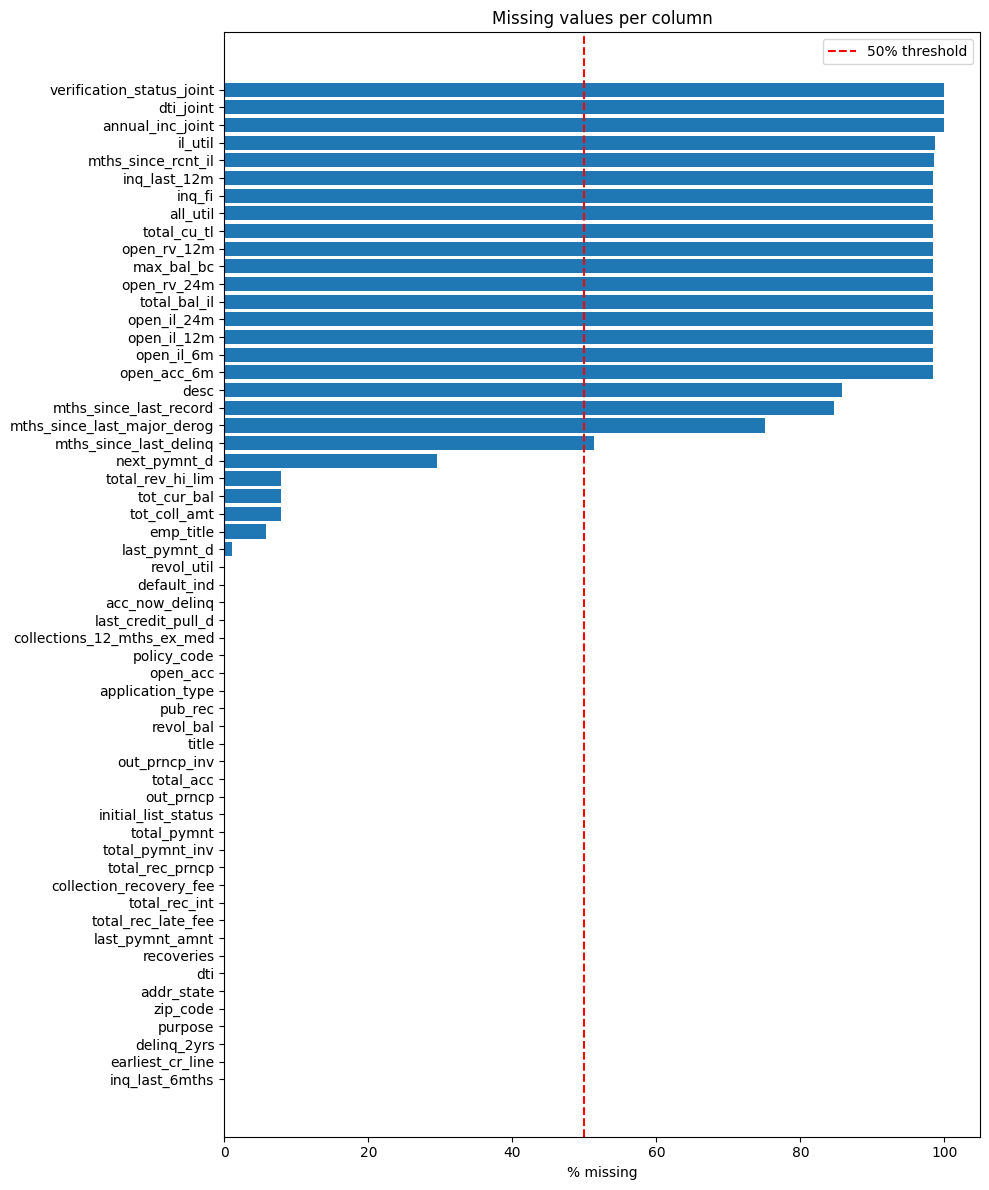

In [442]:
total = df.count()
missing = df.select([
    (count(when(col(c).isNull(), c)) / total * 100).alias(c)
    for c in df.columns
]).toPandas().T.reset_index()
missing.columns = ['column', 'pct_missing']
missing = missing.sort_values('pct_missing', ascending=True)
missing = missing[missing['pct_missing'] > 0]

plt.figure(figsize=(10, 12))
plt.barh(missing['column'], missing['pct_missing'])
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.xlabel('% missing')
plt.title('Missing values per column')
plt.legend()
plt.tight_layout()
plt.show()

### Heat map feature correlation

In [443]:
numeric_types = {"int", "bigint", "float", "double"}
numeric_cols = [f.name for f in df.schema.fields if f.dataType.simpleString() in numeric_types]
print(numeric_cols)

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'inq_last_12m', 'default_ind']


In [444]:
to_numeric = [
      'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
      'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
      'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog',
      'acc_now_delinq', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
      'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
      'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt',
      'policy_code', 'annual_inc_joint', 'dti_joint', 'tot_coll_amt', 'tot_cur_bal', 
      'total_rev_hi_lim','open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
      'mths_since_rcnt_il', 'total_bal_il', 'il_util',
      'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
      'inq_fi', 'total_cu_tl',
  ]

for c in to_numeric:
    df = df.withColumn(c, expr(f"try_cast({c} as double)"))

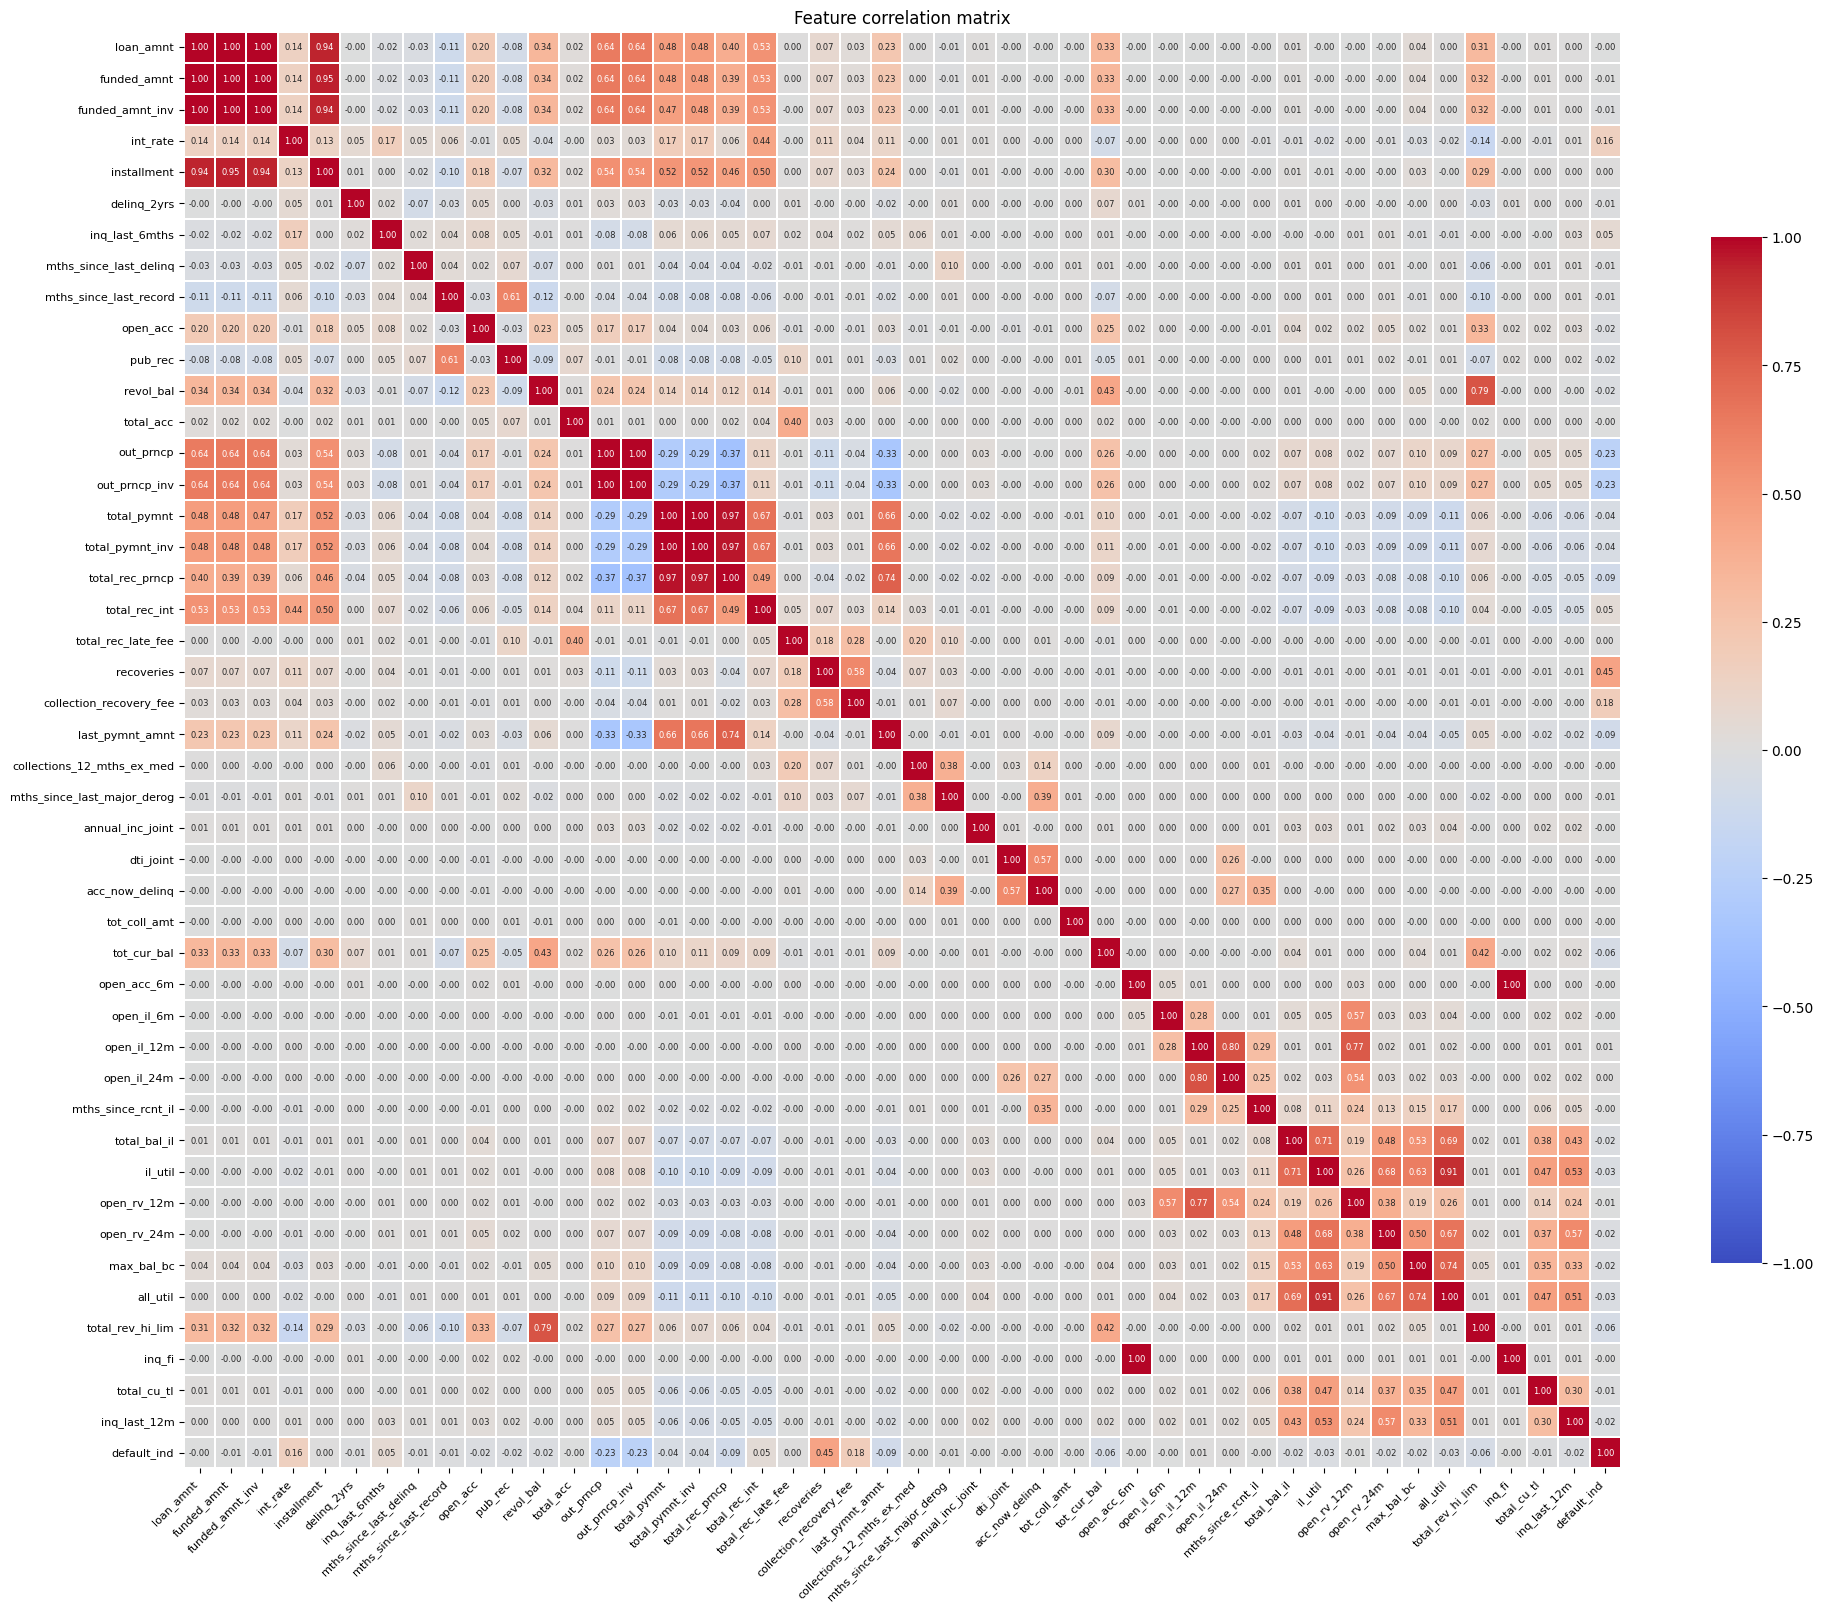

In [445]:
numeric_cols = [c for c, t in df.dtypes if t in ('int','bigint','double','float')]
numeric_cols = [c for c in numeric_cols if c not in ('id','member_id','policy_code')]

df_numeric = df.select(*numeric_cols).na.fill(0)
assembler = VectorAssembler(inputCols=numeric_cols, outputCol='features')
corr_matrix = Correlation.corr(
    assembler.transform(df_numeric).select('features'), 'features'
).head()[0].toArray()

# Mask the upper triangle — duplicate info

plt.figure(figsize=(20, 18))     
sns.heatmap(
    corr_matrix,
    xticklabels=numeric_cols,
    yticklabels=numeric_cols,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True,                 
    annot=True, fmt='.2f',       
    annot_kws={'size': 6},        
    cbar_kws={'shrink': 0.6},     
    linewidths=0.3, linecolor='white'
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.title('Feature correlation matrix', fontsize=12)
plt.tight_layout()
plt.show()

### Numerif features to target class

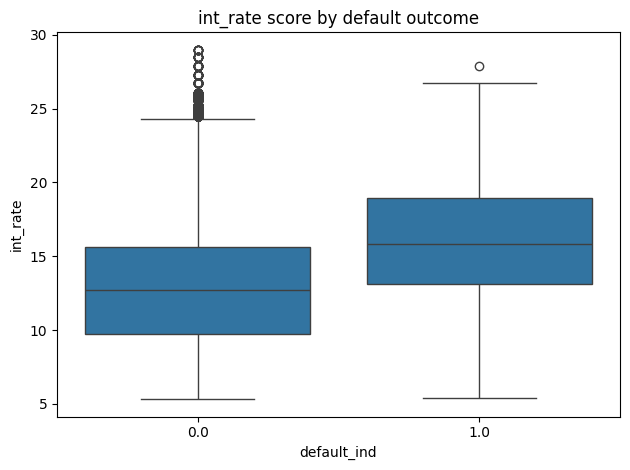

/var/folders/fn/74hvcm156ls3k9tt04qhzlv40000gn/T/ipykernel_20605/1756991201.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


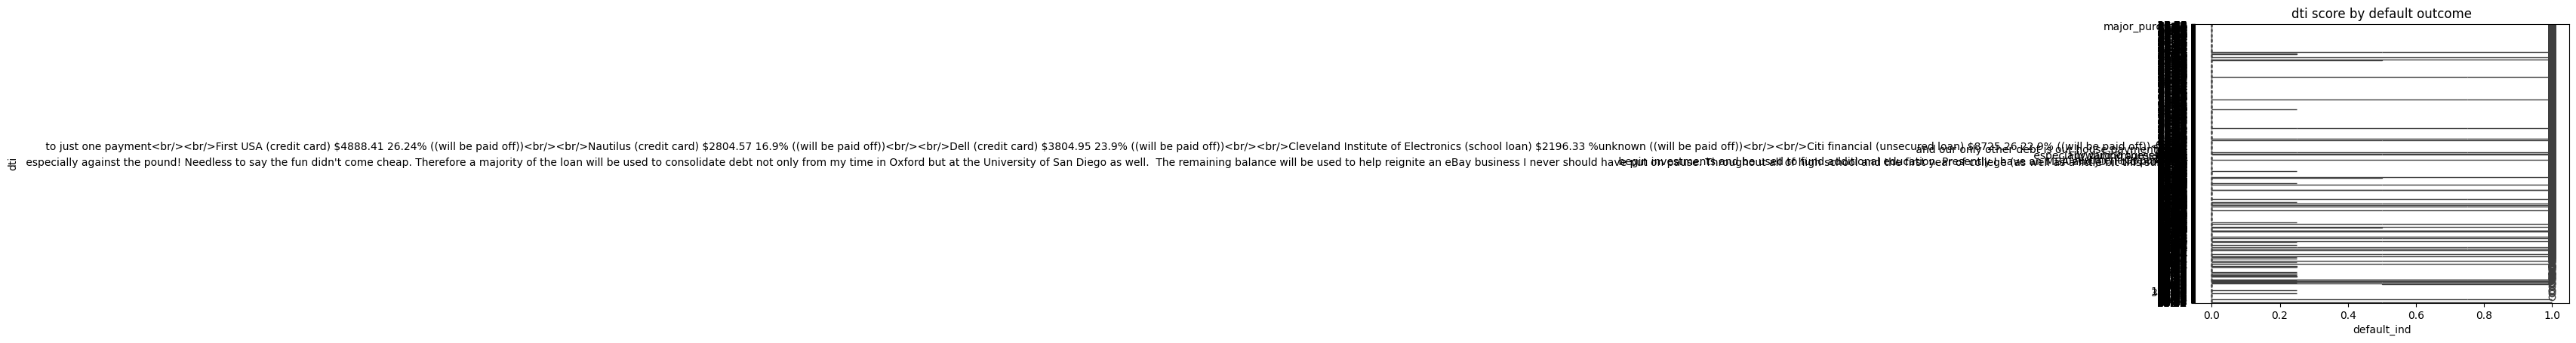

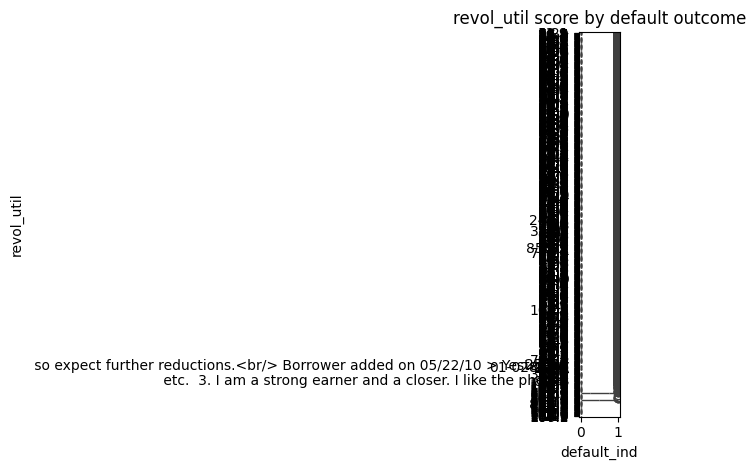

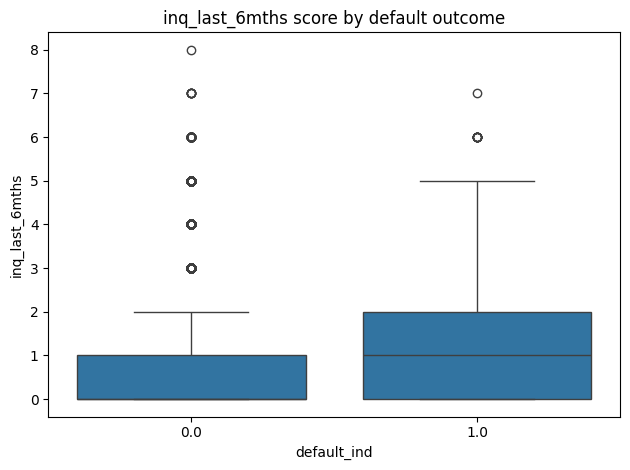

In [446]:
dt_to_plot = ['int_rate', 'dti', 'revol_util', 'inq_last_6mths']
for f in dt_to_plot:
    data = df.select(f, 'default_ind') \
         .filter(col('int_rate').isNotNull()) \
         .sample(0.1, seed=42).toPandas() 
    sns.boxplot(data=data, x='default_ind', y=f)
    plt.title(f'{f} score by default outcome')
    plt.tight_layout()
    plt.show()

### Check to see if these features differ between defaulters and non defaulters

In [447]:
from pyspark.sql.functions import mean

def plot_default_rate_by(cat_col, min_count=500, figsize=(8, 5), top_n=None):
      """Bar chart of default rate by category, sorted descending.
         min_count filters out tiny groups that are noisy.
         top_n optionally keeps only the highest-default-rate N categories."""
      stats = (df.groupBy(cat_col)
                 .agg(mean('default_ind').alias('default_rate'),
                      count('*').alias('n'))
                 .filter(col('n') >= min_count)
                 .orderBy('default_rate', ascending=False)
                 .toPandas())

      if top_n:
          stats = stats.head(top_n)

      overall = df.select(mean('default_ind')).first()[0]

      plt.figure(figsize=figsize)
      bars = plt.barh(stats[cat_col].astype(str), stats['default_rate'])
      plt.axvline(overall, color='red', linestyle='--',
                  label=f'Overall ({overall:.1%})')
      plt.xlabel('Default rate')
      plt.title(f'Default rate by {cat_col}')
      plt.gca().invert_yaxis()  
      for bar, n in zip(bars, stats['n']):
          plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                   f' n={n:,}', va='center', fontsize=7)
      plt.legend()
      plt.tight_layout()
      plt.show()

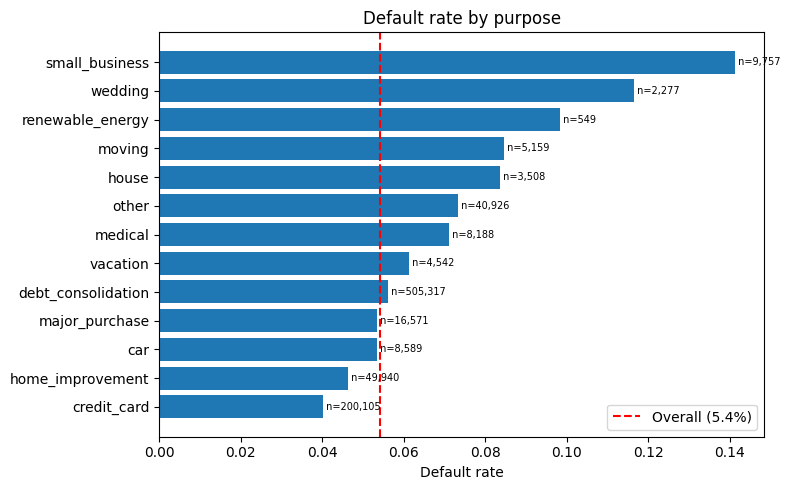

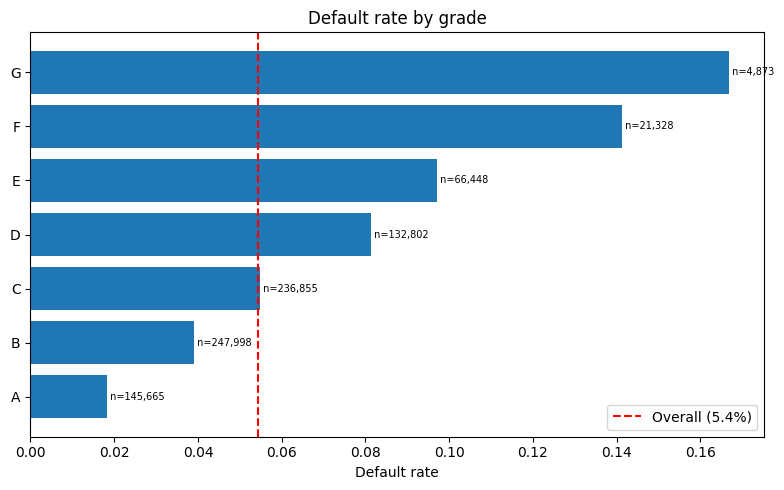

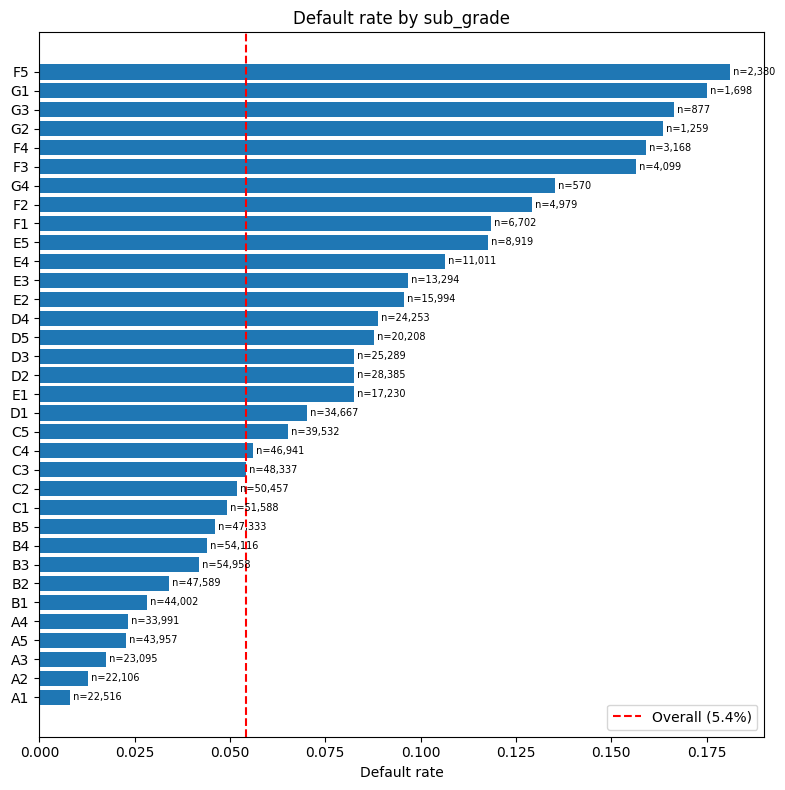

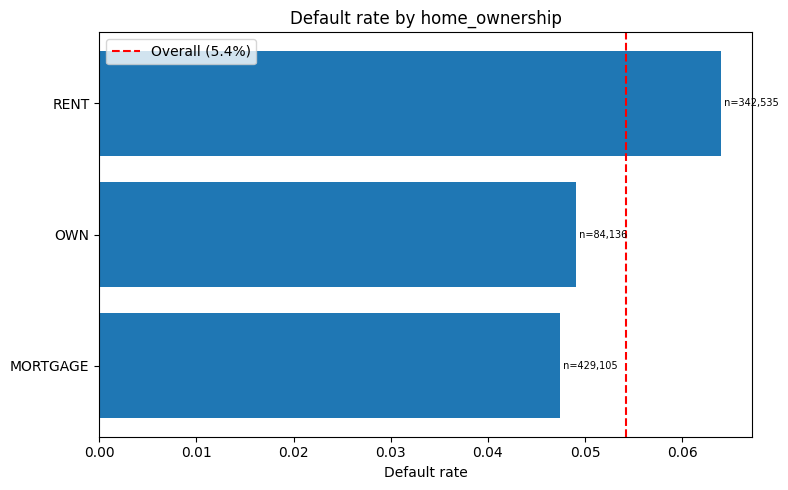

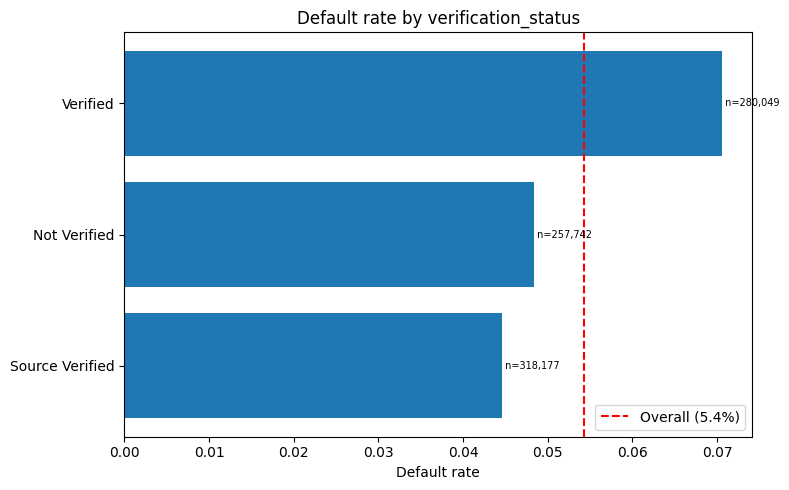

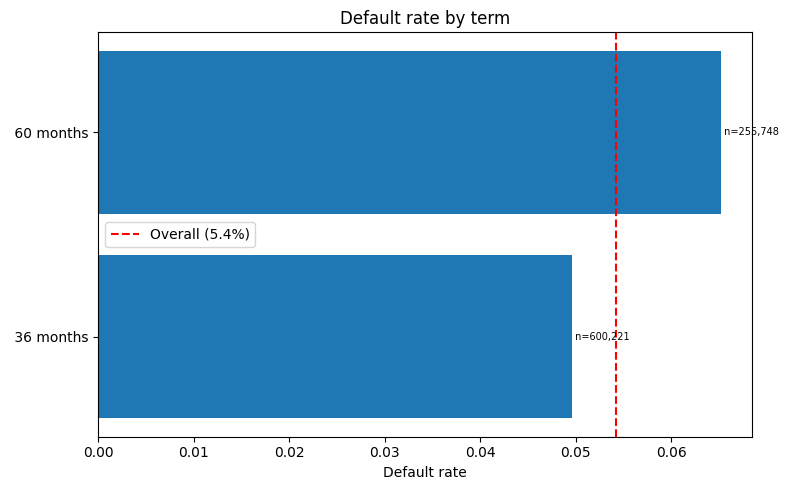

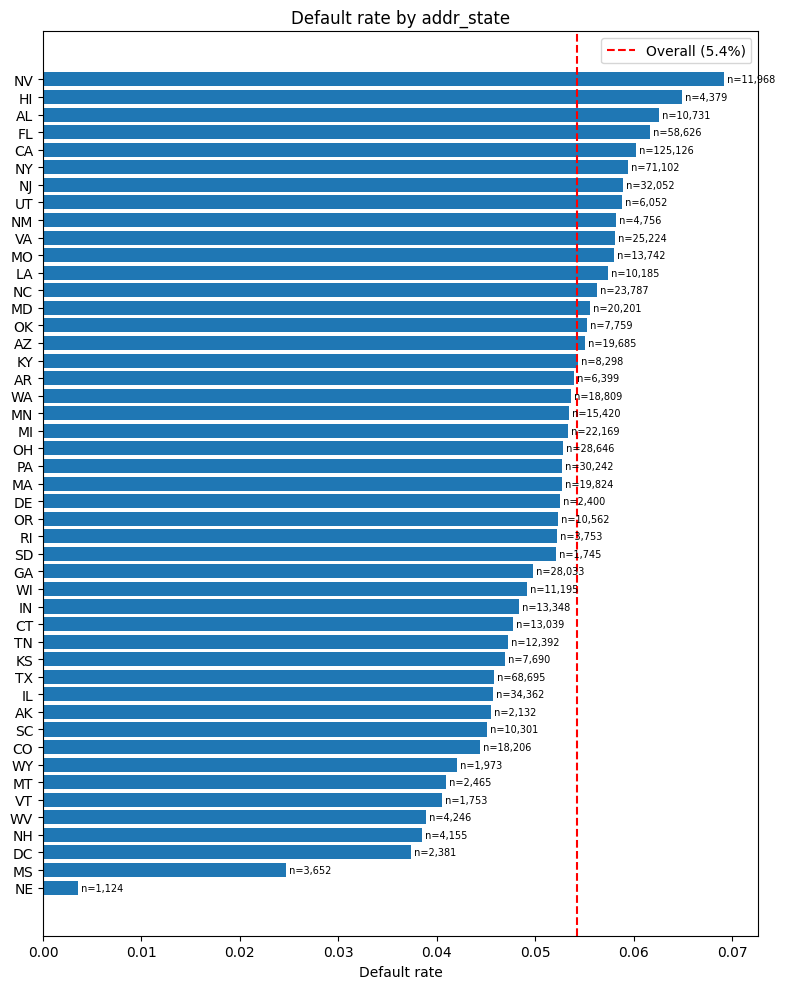

In [448]:
plot_default_rate_by('purpose')
plot_default_rate_by('grade')                  
plot_default_rate_by('sub_grade', figsize=(8, 8))
plot_default_rate_by('home_ownership')
plot_default_rate_by('verification_status')
plot_default_rate_by('term')                   
plot_default_rate_by('addr_state', figsize=(8, 10))

### Numeric features 

In [449]:
annual_cnt = df.groupBy('annual_inc').count().toPandas()

In [450]:
annual_cnt.to_csv('annual_inc_csv')

In [451]:
# Check if there's any malformed values, if there's any make it to null then drop it.
df = df.withColumn('annual_inc', expr("try_cast(annual_inc as double)"))
null = df.filter(col('annual_inc').isNull()).count()
print(f"Null: {null}")
df = df.na.drop(subset=['annual_inc'])


Null: 1


In [452]:
df = df.withColumn("annual_inc", col("annual_inc").cast("double"))

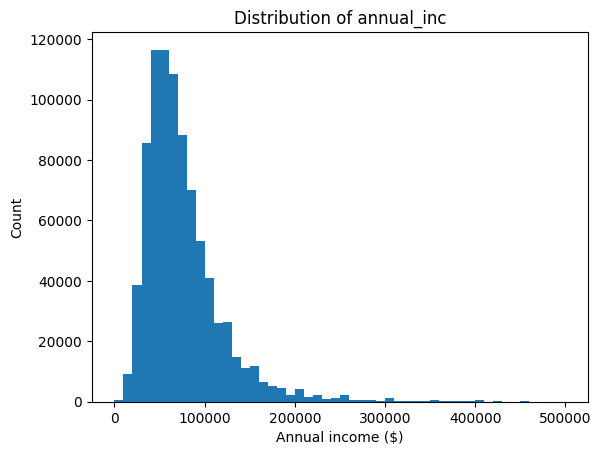

In [453]:
# For one feature
data = df.select('annual_inc').filter(col('annual_inc') < 500000.0).toPandas()
plt.hist(data['annual_inc'], bins=50)
plt.xlabel('Annual income ($)')
plt.ylabel('Count')
plt.title('Distribution of annual_inc')
plt.show()

In [454]:
# Check if there's any malformed values, if there's any make it to null then drop it.
df = df.withColumn('dti', expr("try_cast(dti as double)"))
null = df.filter(col('dti').isNull()).count()
print(f"Null: {null}")


Null: 225


In [455]:
df = df.withColumn("dti", col("dti").cast("double"))

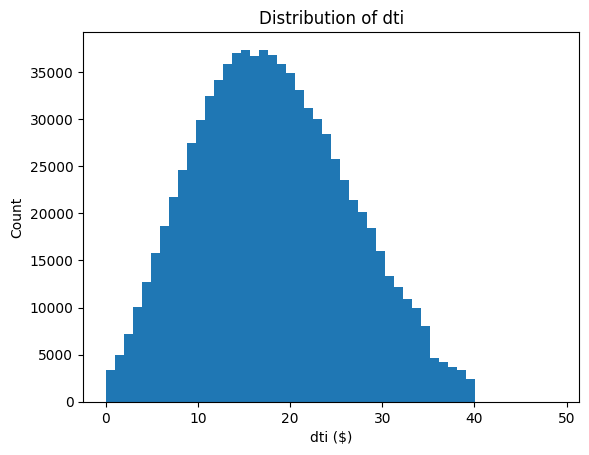

In [456]:
# For one feature
data = df.select('dti').filter(col('dti') < 50.0).toPandas()
plt.hist(data['dti'], bins=50)
plt.xlabel('dti ($)')
plt.ylabel('Count')
plt.title('Distribution of dti')
plt.show()

In [457]:
df = df.withColumn("int_rate", col("int_rate").cast("double"))


In [458]:
def plot_histogram(df, col_name, bins=50, clip_quantile=0.99, xlim=None, title=None):
    query = df.filter(col(col_name).isNotNull())
    if clip_quantile < 1.0:
        upper = query.approxQuantile(col_name, [clip_quantile], 0.01)[0]
        query = query.filter(col(col_name) <= upper)

    data = query.select(col_name).toPandas()

    plt.figure(figsize=(8, 5))
    plt.hist(data[col_name], bins=bins, edgecolor='white', linewidth=0.3)
    plt.xlabel(col_name)
    plt.ylabel('Count')
    plt.title(title or f'Distribution of {col_name}')
    if xlim:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()


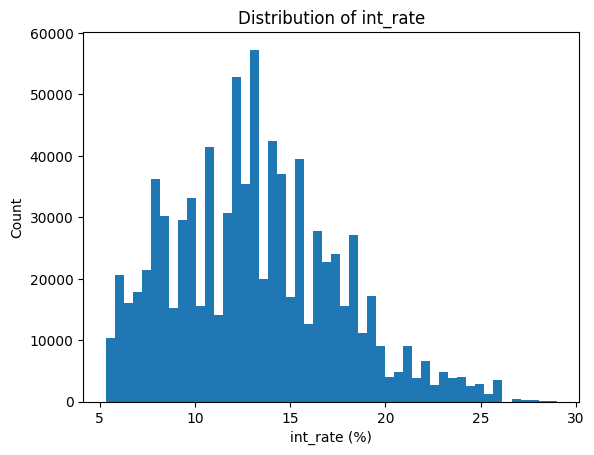

In [459]:
# For one feature
data = df.select('int_rate').filter(col('int_rate') < 100.0).toPandas()
plt.hist(data['int_rate'], bins=50, linewidth=30)
plt.xlabel('int_rate (%)')
plt.ylabel('Count')
plt.title('Distribution of int_rate')
plt.show()

In [460]:
df = df.withColumn('revol_util', expr("try_cast(revol_util as double)"))
null = df.filter(col('dti').isNull()).count()
print(f"Null: {null}")
df = df.na.drop(subset=['revol_util'])


Null: 225


In [461]:
df = df.withColumn('revol_util', col('revol_util').cast("double"))

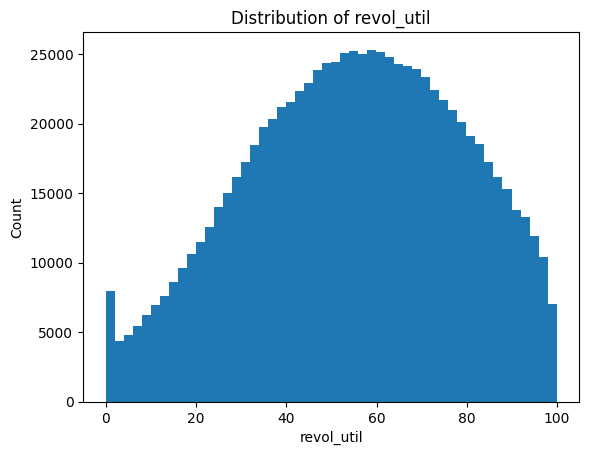

In [462]:
data = df.select('revol_util').filter(col('revol_util')<100.0).toPandas()
plt.hist(data['revol_util'], bins=50)
plt.xlabel('revol_util')
plt.ylabel('Count')
plt.title('Distribution of revol_util')
plt.show()


In [463]:
df = df.withColumn('loan_amnt', expr("try_cast(loan_amnt as double)"))
null = df.filter(col('loan_amnt').isNull()).count()
print(f"Null: {null}")

Null: 0


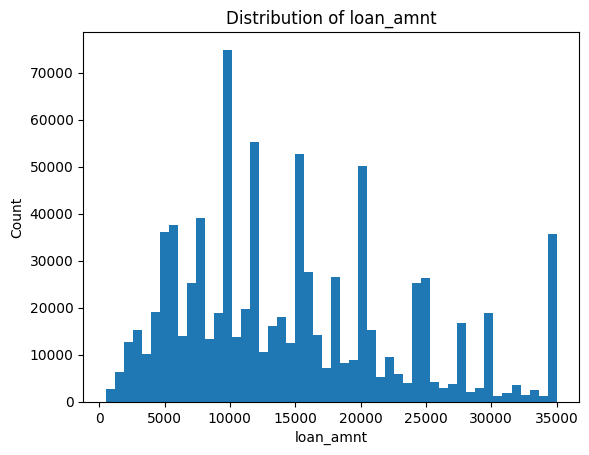

In [464]:
# df = df.withColumn('loan_amnt', col('loan_amnt').cast("double"))
data = df.select('loan_amnt').filter(col('loan_amnt')<100000).toPandas()
plt.hist(data['loan_amnt'], bins=50)
plt.xlabel('loan_amnt')
plt.ylabel('Count')
plt.title('Distribution of loan_amnt')
plt.show()


### EDA VISUALIZATION EXPLANATION

### 1. Target class distribution

The class dist of defaulters and non defaulters isn't balance. **5.4% (default) to 94.5% non-default**.

### 2. Missing values

Top missing values are over half of them, meaning needed to drop.

### 3. Heatmap

Confirmed leakage, legitimate predictors, multicollinearity hotspots.

The heatmap shows something:

### 4. Boxplot outcome by feature

- **`int_rate`** — Defaulters have higher interest rate, the median is ~15% higher, which higher than non-defaulters ~12%. The IQR also aren't heavily overlap, means that `int_rate` realibly distinguish between the two groups.
- **`dti`** — Defaulters and non-defaulters have the same dti distribution. With the same median and heavily overlap IQR. Meaning DTI doesn't discriminate between them in this datasets.
- **`revol_util`** — Defaulters seem to have higher revolving credit utilization than non-defaulters (median ~60% vs ~56%). However, the boxes overlap heavily. It does seperates the distribution, but not the classes.
- **`inq_last_6mths`** — Here defaulters obviously had more recent credits compare to non-defaulters (median 1 vs 0). Morover, the distribution is clearly differ.
- **`annual_inc`** — Defaulters have systematically lower incomes — the median is ~$7k lower. However, the heavy IQR overlap means income alone is a weak discriminator: most defaulters earn within the same range as most non-defaulters. Income shifts the distribution slightly but doesn't separate the classes.

### 5. Categorical default-rate charts

Baseline default rate is **5.4%** (the red dashed line on every chart). Bars above the line = higher risk than average, below = lower risk.

- **`grade`** — strongest categorical predictor. Perfectly monotonic from A (1.7%) → G (16.6%). A G-grade borrower is ~10× more likely to default than an A-grade. This is by construction since LC built grade specifically to rank-order default risk.
- **`sub_grade`** — same pattern as grade but finer (35 buckets, A1 to G5). A1 = 0.8% default, F5/G1 = ~18%. Mostly redundant with grade — pick one for modeling.
- **`purpose`** — strong predictor with intuitive spread:
  - Highest risk: small_business (14.2%), wedding (11.7%), renewable_energy (9.9%)
  - Lowest risk: credit_card (4.0%), home_improvement (4.6%), car (5.3%)
- **`term`** — clear signal. 36 months: 4.9% default vs 60 months: 6.5%. 60-month loans default ~33% more often due to longer time exposure + selection effect (borrowers who choose 60-month often can't afford 36-month payments).
- **`home_ownership`** — modest predictor. RENT: 6.4%, OWN: 4.9%, MORTGAGE: 4.8%. Renters default more; OWN and MORTGAGE are nearly identical (interesting — outright ownership doesn't protect more than having a mortgage).
- **`verification_status`** — counterintuitive and slide-worthy. Verified: 7.0%, Not Verified: 4.9%, Source Verified: 4.5%. Verified income has HIGHER default rate because LC selectively verifies riskier-looking applicants. The feature proxies underlying risk, not borrower quality.
- **`addr_state`** — weak predictor. Range 3% (NE) to 7% (NV). Some patterns (tourist/recession-sensitive states cluster higher) but the overall signal is modest. Probably not worth a top-7 slot.

### 6. Numerical distribution shape

Use this section to talk about distribution shape observations — not predictive power (that's the boxplot section).

- **`annual_inc`** — heavily right-skewed. Most borrowers earn $30k-$100k, with a long tail extending to extreme outliers ($9M reported incomes). Required clipping for visualization. Justifies log-transformation for linear/neural models; tree models can use raw values.
- **`dti`** — bell-shaped distribution, truncated at ~40. The cap at 40 reflects LC's underwriting cutoff — applicants with DTI > 40 are rejected at intake. This introduces selection bias: the dataset only represents the funded subset of applicants, and the model has no exposure to higher-DTI borrowers.
- **`int_rate`** — multi-modal distribution reflecting LC's grade-based pricing tiers (grade A around 7%, grade D around 17%, etc.). The visible "humps" in the histogram are the grade buckets.
- **`revol_util`** — bimodal-skewed. Small spike at 0% (disciplined "transactor" borrowers who never carry a balance), bulk peaks at 50-60% (typical LC borrower applying to consolidate existing credit card debt). Tail toward 100% identifies high-risk subgroup with no credit buffer remaining.
- **`loan_amnt`** — discrete-looking distribution with visible spikes at round-number amounts ($5k, $10k, $15k, $20k, $25k, $30k, $35k). Reflects human preference for round figures when requesting loans.
- **`fico_range_low`** — bell-shaped, bounded 660-845 (LC requires minimum FICO 660 for approval). Distribution centered around 690-700, reflecting LC's borrower pool quality (slightly above subprime, below prime).

## Data Cleaning

Based on the EDA findings above, we now clean the dataset to prepare it for modelling. The cleaning is also packaged as a standalone script (`cleaning.py`) for reproducibility — the cells below mirror that script.

**Steps:**
1. Drop useless / redundant / leakage columns
2. Drop rows with null target
3. Parse string fields (`term`, `emp_length`, dates, percentages)
4. Outlier capping + log transform
5. Missingness audit
6. Impute remaining nulls (median for numeric, `'unknown'` for categorical)
7. Save outputs (`cleaned_loan_data.parquet` for Spark MLlib, `cleaned_loan_data_csv/` for TensorFlow)

### Step 1 — Drop useless / redundant / leakage columns

Removes 3 groups of columns:
- **Useless**: constants, identifiers, free text, joint-application fields, the il/rv block (98% null), high-missingness `mths_since_last_*`, redundant `funded_amnt*`, high-cardinality `zip_code`.
- **Leakage**: post-origination columns (`recoveries`, `out_prncp`, `total_pymnt*`, etc.) that are only populated *after* default occurs — including them would leak the target.

In [465]:
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

# ---------- Step 1: drop useless / leakage / redundant columns ----------
useless_cols = [
    # Constants / near-zero variance
    'policy_code', 'pymnt_plan',
    # Identifiers
    'id', 'member_id', 'url',
    # Free text — too sparse / too high cardinality
    'desc', 'emp_title', 'title',
    # Joint application fields (~100% null in this dataset)
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    # il/rv block (~98% null — added late to LC schema)
    'il_util', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m',
    'mths_since_rcnt_il', 'total_bal_il',
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
    'inq_fi', 'total_cu_tl', 'inq_last_12m', 'total_rev_hi_lim',
    # High missingness (>50%) — confirmed from EDA
    'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_last_delinq',
    # Redundant — correlation ~1.00 with loan_amnt
    'funded_amnt', 'funded_amnt_inv',
    # High-cardinality categorical; addr_state captures regional signal
    'zip_code',
]

# Post-origination leakage — recorded after default occurs
leakage_cols = [
    'recoveries', 'collection_recovery_fee',
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',
    'last_fico_range_high', 'last_fico_range_low',
    'last_credit_pull_d',
    'loan_status',
]

cols_to_drop = [c for c in (useless_cols + leakage_cols) if c in df.columns]
df = df.drop(*cols_to_drop)
print(f"After Step 1: {len(df.columns)} columns (dropped {len(cols_to_drop)})")

After Step 1: 29 columns (dropped 44)


### Step 2 — Drop rows with null target

We can't train on rows where `default_ind` is unknown. ~223 rows are dropped.

In [466]:
# ---------- Step 2: drop rows with null target ----------
before = df.count()
df = df.filter(F.col('default_ind').isNotNull())
after = df.count()
print(f"Dropped {before - after:,} rows with null default_ind")
df.groupBy('default_ind').count().orderBy('default_ind').show()

Dropped 158 rows with null default_ind
+-----------+------+
|default_ind| count|
+-----------+------+
|          0|808911|
|          1| 46387|
+-----------+------+



### Step 3 — Parse string fields to numeric

Converts:
- `int_rate`, `revol_util` — strip any `%` and cast to double.
- `term` — extract the integer (`" 36 months" → 36`).
- `emp_length` — map `"< 1 year"`, `"1 year"`, …, `"10+ years"`, `"n/a"` to integers 0–10 / null.
- `issue_d`, `earliest_cr_line` — parse as `dd-MM-yyyy` dates, then derive `cr_history_years = issue_d - earliest_cr_line` (in years) and drop the raw date strings.
- All remaining numeric-looking string columns — `try_cast` to double (NULL on malformed values).

In [ ]:

df = df.withColumn('int_rate',
    F.regexp_replace(F.col('int_rate').cast('string'), '%', '').cast(DoubleType()))
df = df.withColumn('revol_util',
    F.regexp_replace(F.col('revol_util').cast('string'), '%', '').cast(DoubleType()))

df = df.withColumn('term',
    F.regexp_extract(F.col('term'), r'(\d+)', 1).cast(IntegerType()))

df = df.withColumn('emp_length',
    F.when(F.col('emp_length') == '< 1 year', 0)
     .when(F.col('emp_length') == '10+ years', 10)
     .when(F.col('emp_length') == 'n/a', None)
     .otherwise(F.regexp_extract(F.col('emp_length'), r'(\d+)', 1).cast(IntegerType())))

df = df.withColumn('_issue_date', F.to_date(F.col('issue_d'), 'dd-MM-yyyy'))
df = df.withColumn('_earliest_cr', F.to_date(F.col('earliest_cr_line'), 'dd-MM-yyyy'))
df = df.withColumn('cr_history_years',
    F.round(F.datediff(F.col('_issue_date'), F.col('_earliest_cr')) / 365.25, 1))
df = df.drop('issue_d', 'earliest_cr_line', '_issue_date', '_earliest_cr')

to_numeric = [
    'annual_inc', 'dti', 'loan_amnt', 'installment',
    'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
    'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq',
    'tot_coll_amt', 'tot_cur_bal',
]
for c in to_numeric:
    if c in df.columns:
        df = df.withColumn(c, F.expr(f"try_cast({c} as double)"))

print("Step 3 complete — string fields parsed to numeric")

Step 3 complete — string fields parsed to numeric


### Step 4 — Outlier capping + log transform

- `revol_util` capped at 100% (rare data-entry artifacts above 100).
- `dti` capped at 50 (LC underwriting cuts off around 40; values up to 9999 are "not calculable" sentinels).
- `annual_inc` capped at the 99th percentile to tame extreme self-reported outliers (we saw incomes up to $9.5M).
- Added `log_annual_inc = log1p(annual_inc)` — useful for linear / NN models that prefer normalised distributions; tree models can still use raw `annual_inc`.

In [ ]:
df = df.withColumn('revol_util',
    F.when(F.col('revol_util') > 100, 100.0).otherwise(F.col('revol_util')))

df = df.withColumn('dti',
    F.when(F.col('dti') > 50, 50.0).otherwise(F.col('dti')))
p99 = df.selectExpr("percentile_approx(annual_inc, 0.99, 10000)").first()[0]
df = df.withColumn('annual_inc',
    F.when(F.col('annual_inc') > p99, p99).otherwise(F.col('annual_inc')))
print(f"Capped annual_inc at p99 = ${p99:,.0f}, dti at 50")

df = df.withColumn('log_annual_inc', F.log1p(F.col('annual_inc')))
print("Created log_annual_inc for linear/NN models")

Capped annual_inc at p99 = $250,000, dti at 50
Created log_annual_inc for linear/NN models


### Step 5 — Missingness audit

Recompute the per-column missingness on the post-cleaning frame, so we know what's left to impute. Uses a type-aware check (only test for empty string on string columns; numeric columns just check for NULL).

In [ ]:
total = df.count()
missing_exprs = []
for c, t in df.dtypes:
    if t == 'string':
        cond = F.col(c).isNull() | (F.col(c) == '')
    else:
        cond = F.col(c).isNull()
    missing_exprs.append((F.count(F.when(cond, c)) / total).alias(c))
missing_pct = df.select(missing_exprs).first().asDict()

print("\nColumns with any missing values:")
print(f"{'Column':35s} {'% missing':>10s}")
print('-' * 50)
for c, pct in sorted(missing_pct.items(), key=lambda x: -x[1]):
    if pct > 0:
        print(f"{c:35s} {pct*100:>9.2f}%")


Columns with any missing values:
Column                               % missing
--------------------------------------------------
tot_coll_amt                             7.83%
tot_cur_bal                              7.83%
emp_length                               5.03%
collections_12_mths_ex_med               0.01%


### Step 6 — Impute remaining nulls

- **Numeric columns**: fill with the column median (robust to skew, unlike the mean).
- **Categorical columns**: fill with the literal string `'unknown'` — preserves the "missingness pattern" as its own category instead of guessing.

In [470]:
# ---------- Step 6: impute remaining nulls ----------
numeric_types = ('int', 'bigint', 'double', 'float')
numeric_cols = [c for c, t in df.dtypes if t in numeric_types and c != 'default_ind']
categorical_cols = [c for c, t in df.dtypes if t == 'string']
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Median imputation for numeric columns
for c in numeric_cols:
    if missing_pct.get(c, 0) > 0:
        med = df.approxQuantile(c, [0.5], 0.01)
        if med:
            df = df.fillna({c: med[0]})

# 'unknown' for categorical columns
for c in categorical_cols:
    if missing_pct.get(c, 0) > 0:
        df = df.fillna({c: 'unknown'})

print("Step 6 complete — all nulls imputed")

Numeric columns: 20
Categorical columns: 8


Step 6 complete — all nulls imputed


### Step 7 — Sanity checks + save outputs

Prints the final shape, default rate, and schema, then writes two artefacts:
- `cleaned_loan_data.parquet/` — fast, schema-preserving format for the Spark MLlib pipeline.
- `cleaned_loan_data_csv/` — single-file CSV for the TensorFlow pipeline (TF can't read Parquet natively).

In [ ]:
print(f"Final shape: {df.count():,} rows x {len(df.columns)} cols")
print(f"Default rate: {df.select(F.mean('default_ind')).first()[0]:.4f}  (expected ~0.054)")
print("\nFinal schema:")
for c, t in df.dtypes:
    print(f"  {c:30s} {t}")

df.write.mode('overwrite').parquet('cleaned_loan_data.parquet')
print("\nSaved cleaned_loan_data.parquet   (for Spark MLlib pipeline)")

df.coalesce(1).write.mode('overwrite').option('header', True).csv('cleaned_loan_data_csv')
print("Saved cleaned_loan_data_csv/      (for TensorFlow pipeline)")

Final shape: 855,298 rows x 29 cols
Default rate: 0.0542  (expected ~0.054)

Final schema:
  loan_amnt                      double
  term                           int
  int_rate                       double
  installment                    double
  grade                          string
  sub_grade                      string
  emp_length                     int
  home_ownership                 string
  annual_inc                     double
  verification_status            string
  purpose                        string
  addr_state                     string
  dti                            double
  delinq_2yrs                    double
  inq_last_6mths                 double
  open_acc                       double
  pub_rec                        double
  revol_bal                      double
  revol_util                     double
  total_acc                      double
  initial_list_status            string
  collections_12_mths_ex_med     double
  application_type               st

26/05/17 19:43:29 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 95,00% for 8 writers
26/05/17 19:43:29 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 84,44% for 9 writers
26/05/17 19:43:29 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 76,00% for 10 writers
26/05/17 19:43:29 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 69,09% for 11 writers
26/05/17 19:43:31 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 76,00% for 10 writers
26/05/17 19:43:31 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 84,44% for 9 writers
26/05/17 19:43:31 WARN MemoryManager: Total allocation exceeds 95,0


Saved cleaned_loan_data.parquet   (for Spark MLlib pipeline)


Saved cleaned_loan_data_csv/      (for TensorFlow pipeline)


### EDA Summary: 7 Most & 7 Least Relevant Features

Based on the visualisations above (target imbalance, missingness, correlation heatmap, numeric distributions, boxplots by default outcome, and default-rate-by-category charts), we rank features by univariate relevance to `default_ind`.

**Framing:** the *most relevant* list is restricted to **pre-origination** features only. Post-origination columns (`recoveries`, `out_prncp`, `total_pymnt`, `total_rec_late_fee`, `last_pymnt_amnt`, `collection_recovery_fee`) have the highest raw correlations with `default_ind` but are recorded *after* default occurs — using them would leak the target into a predictive model. They are excluded from "most relevant" and will be dropped before modelling.

### 7 Most Relevant:

- **`grade` / `sub_grade`** — Monotonic default rate 0.8% → 18.1% across sub_grades; LC's purpose-built risk score.
- **`int_rate`** — Boxplot shows clear separation; |corr| ≈ 0.16; numeric proxy for grade.
- **`purpose`** — 3.5× default-rate spread across categories (4% → 14%).
- **`term`** — 60-month default rate 33% higher than 36-month (6.5% vs 4.9%).
- **`inq_last_6mths`** — Boxplot median shifts up; |corr| ≈ 0.07; classic credit-seeking signal.
- **`revol_util`** — Boxplot shows moderate separation; tail near 100% indicates high-risk segment.
- **`verification_status`** — Counterintuitive: Verified 7.0% vs Not Verified 4.5% — reflects LC verifying riskier applicants.

### 7 Least Relevant:

- **`policy_code`, `pymnt_plan`** — Zero / near-zero variance (one dominant value).
- **Joint application fields** (`annual_inc_joint`, `dti_joint`, `verification_status_joint`) — ~100% missing; only populated for joint applications.
- **IL/RV block** (12 features: `open_acc_6m`, `open_il_*`, `open_rv_*`, `il_util`, `max_bal_bc`, `all_util`, `inq_fi`, `total_cu_tl`, `total_bal_il`, `mths_since_rcnt_il`) — 98% missing; added late to LC schema.
- **`mths_since_last_*`** (3 features) — 51–85% missing.
- **`desc`, `emp_title`, `title`** — Free text, very high cardinality (60k–290k unique); no generalisation.
- **`id`, `member_id`** — Unique identifiers; no predictive value.
- **`funded_amnt`, `funded_amnt_inv`** — Perfectly redundant with `loan_amnt` (corr ≈ 1.00).

### Note on `dti`

A priori, debt-to-income should be a strong default predictor. However, univariate evidence in this dataset shows near-identical distributions across both classes (|corr| ≈ 0.004, overlapping boxplots). We **retain `dti` as a modelling feature** because tree-based models may capture non-linear thresholds (e.g. risk spikes only above DTI ≈ 35) that univariate statistics miss — but it does not qualify for the top 7 under our evidence-based criterion.

### Note on FICO

FICO scores (typically the strongest credit-risk predictor) are not included in this dataset. We use `sub_grade` and `int_rate` as proxies, since LC's internal grading is partially derived from FICO.